# 05b — Scaling the Surprise Strategy: CPI Only vs CPI + Other Macro Surprises (ES) — YM

## Purpose

Notebook 04 showed that trading ES in the direction of the **CPI surprise** earns a net Sharpe of about 1.0, but only about **7–11 trades a year**. The peer DTW strategy (Jack Duncan) trades about **185 times a year on ES**.

This notebook asks:

> **If we trade the surprises of many US macro releases, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

The final section compares **CPI only** against **CPI + other surprises** on trades per year, P&L, return, Sharpe, drawdown, hit rate and costs.

**Scope:** ES only, so the comparison with the peer ES strategy is like for like.

**Credits:** the release-family rule, the impact screen and the volatility-proportional sizing come from **Jack Duncan** (`blackrock-intraday/jack/strategy_proposal.md`). The 5σ winsorisation of surprises comes from **Aaryen Mehta**. The causal surprise standardisation, the executable entry and the walk-forward engine come from this project (Notebooks 01–04).

> **05b — E-mini Dow (YM).** This notebook is Notebook 05 (ES) run on **YM**, with identical code and parameters.
> - Prices: Jack Duncan's cleaned 1-minute file `futures_1min_clean_v3_YM.parquet` (team repo), roll-adjusted the same way. The variables `es` / `es_adj` hold **NQ** bars (names kept from the ES notebook).
> - Costs: 2 ticks + $4.50 per round trip on the YM contract (tick 1 index point, $5 per point).
> - Outputs are saved as `nb05b_YM_*` (results, figures), so nothing from the ES notebook is overwritten.
> - **Text cells are copied from the ES notebook.** Where they quote ES numbers or say "ES", they describe the ES study; the YM results are in the outputs.
> - Run order: 03b → 04b → 05b → 06b for the same market (each reads the previous one's files).

## Notebook Workflow

| Step | What happens |
|---|---|
| 1 | Setup and pre-registered parameters |
| 2 | Read every US release in the Bloomberg workbook and group lines into release **families** |
| 3 | Causal, winsorised surprise for every line |
| 4 | ES price measures at every release: jump, tradeable 30-min drift, second 30 min, 4-hour volatility |
| 5 | Validation: the CPI trades must reproduce Notebook 04 |
| 6 | **Impact screen**: each year, admit the 10 families the market reacts to most (history only) |
| 7 | Direction: line signs from the jump regression (history only), then family signals |
| 8 | Strategies: CPI only vs all admitted families; flat, surprise-model and volatility sizing; one vs two windows |
| 9 | Performance, per-family results, robustness (periods, costs, random-sign null) |
| 10 | **Final comparison: CPI only vs CPI + other surprises** |

## Methodology: fixed before looking at results

1. **Entry and exit as in Notebook 04.** Entry at the close of the first post-release bar (about 1 minute after the release, "T+1"), exit 30 minutes after the release. The instant jump is **never** traded.
2. **Release families.** Bloomberg lines that print at the same instant (CPI MoM, Core CPI MoM, CPI YoY and so on) are one release. Lines sharing ≥80% of their timestamps form one family.
3. **Surprise.** $z = (\text{actual} - \text{consensus}) / \text{sd of the line's previous surprises}$, with at least 24 prior releases, capped at ±5σ.
4. **Universe (impact screen).** At the start of each year, using **only earlier data**:
   $$\text{impact}_f = \frac{\text{mean}\,|\text{30-min move}| \text{ on } f\text{'s releases}}{\text{mean}\,|\text{30-min move}| \text{ at the same clock time when another family releases}}$$
   The top **K = 10** families are admitted for that year. No P&L is used.
5. **Direction.** Each line's sign comes from regressing the **instant jump** on its surprise over earlier years, which avoids any drift P&L. The family signal is $x = \text{mean}(\text{sign} \times z)$, so $x>0$ always means *good news for ES*.
6. **Three sizing rules:**
   - **Naive:** one unit in the direction of $x$.
   - **Surprise model:** $\hat r = \hat b_f\,x$, re-fitted on the family's earlier releases; trade only if $|\hat r|$ exceeds the cost.
   - **Signal × volatility (Jack):** position ∝ clip($x$, ±3) × 4-hour volatility / its historical median, normalised to about 1 unit on average.
7. **Costs** are the same as Notebook 04: 2 ticks round trip plus $4.50 commission per contract.
8. **Evaluation** covers 2019–2026, the same window as Notebook 04. 2016–2018 is history only.

## 1. Setup and Project Paths

In [1]:
from pathlib import Path
import sys, importlib, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = PROJECT_ROOT / "figures"

MARKET = "YM"                      # this notebook's market
TEAM_DATA = PROJECT_ROOT.parent / "blackrock-intraday" / "data" / "processed"
MARKET_FILE = TEAM_DATA / f"futures_1min_clean_v3_{MARKET}.parquet"   # Jack's cleaned 1-minute file
TICK, MULT = {f"{MARKET}": (0.25, 50.0), "NQ": (0.25, 20.0), "ZN": (1 / 64, 1000.0), "YM": (1.0, 5.0)}[MARKET]   # tick, $ per point
_BARS = {}
def load_market_minute():
    """1-minute bars of MARKET as [close, instrument_id] (loaded once, then cached).
    The variables `es` / `es_adj` below hold THIS market's bars (names kept from the ES notebook)."""
    if "bars" not in _BARS:
        import src.multi_asset as _ma
        _BARS["bars"] = _ma.load_bars(MARKET_FILE, "team_v3")
    return _BARS["bars"]

for d in [RESULTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BBG_FILE = RAW_DIR / "Bloomberg Economic Releases.xlsx"
NB04_LOG = RESULTS_DIR / f"nb04b_{MARKET}_trade_log.csv"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import src.state_conditioning as sc
import src.walk_forward as wf
import src.surprise_universe as su
for m in (sc, wf, su):
    importlib.reload(m)

for f in [BBG_FILE, MARKET_FILE, NB04_LOG]:
    print(f"{f.name:<40s} exists: {f.exists()}")

Bloomberg Economic Releases.xlsx         exists: True
futures_1min_clean_v3_YM.parquet         exists: True
nb04b_YM_trade_log.csv                   exists: True


In [2]:
# ---- market switch: costs, titles --------------------------------------------
if "wf" in globals():                       # walk-forward costs use this market's contract
    wf.ES_TICK, wf.ES_MULTIPLIER = TICK, MULT
import re as _re, matplotlib.axes as _mx, matplotlib.figure as _mf
if not getattr(_mx.Axes.set_title, "_mkt", False):
    _T0_, _S0_ = _mx.Axes.set_title, _mf.Figure.suptitle
    def _set_title(self, label, *a, **k):
        return _T0_(self, _re.sub(r"\bES\b", MARKET, str(label)), *a, **k)
    def _suptitle(self, t, *a, **k):
        return _S0_(self, _re.sub(r"\bES\b", MARKET, str(t)), *a, **k)
    _set_title._mkt = True
    _mx.Axes.set_title, _mf.Figure.suptitle = _set_title, _suptitle
print(f"MARKET = {MARKET} | file: {MARKET_FILE.name} (exists: {MARKET_FILE.exists()}) | tick {TICK:g}, ${MULT:g} per point"
      f" | cost 2 ticks + $4.50 = {2 * TICK + 4.5 / MULT:.4f} points per round trip")

MARKET = YM | file: futures_1min_clean_v3_YM.parquet (exists: True) | tick 1, $5 per point | cost 2 ticks + $4.50 = 2.9000 points per round trip


### 1.1 Pre-registered parameters

In [3]:
HIST_START = "2016-01-01"      # history used for screens, signs and model fits
EVAL_START, EVAL_END = "2019-01-01", "2026-06-30"
EVAL_YEARS = list(range(2019, 2027))
K_FAMILIES = 10                # families admitted each year (Jack's specification)
MIN_TRAIN = 24                 # earlier releases needed before a family is modelled
TICKS_RT, COMMISSION_RT = 2.0, 4.5
THRESHOLD = 1.0                # surprise model trades if |E[r]| > 1 x cost
N_NULL, N_BOOT = 1000, 5000
CPI = "CPI"
PRIMARY_TARGET = "w1"          # T+1 -> T+30, the Notebook 04 window
N_YEARS = (pd.Timestamp(EVAL_END) - pd.Timestamp(EVAL_START)).days / 365.25
print(f"Evaluation {EVAL_START} to {EVAL_END} ({N_YEARS:.2f} years), K = {K_FAMILIES}")

Evaluation 2019-01-01 to 2026-06-30 (7.49 years), K = 10


## 2. US Releases and Release Families

In [4]:
t0 = time.time()
rows = su.load_bloomberg(BBG_FILE)
print(f"Release rows: {len(rows):,}  |  lines (tickers): {rows['ticker'].nunique()}  |  read in {time.time()-t0:.0f}s")
print("Range:", rows["ts_et"].min(), "to", rows["ts_et"].max())

fam = su.build_families(rows)
print(f"\nLines with >= 30 releases since 2013: {len(fam)}  ->  families: {fam['family'].nunique()}")
fam_summary = (fam.groupby("family")
                  .agg(lines=("ticker", "size"), clock=("clock_et", lambda s: s.mode().iat[0]),
                       releases=("n_releases", "max"),
                       example_lines=("event_name", lambda s: "; ".join(list(s)[:4])))
                  .sort_values("lines", ascending=False))
display(fam_summary.head(25))

Release rows: 27,137  |  lines (tickers): 179  |  read in 1s
Range: 2010-01-04 10:00:00-05:00 to 2026-07-17 10:00:00-04:00

Lines with >= 30 releases since 2013: 143  ->  families: 75


,lines,clock,releases,example_lines
family,,,,
Employment Report (NFP),10,08:30,162,Average Hourly Earnings MoM; Average Hourly Ea...
CPI,8,08:30,162,CPI MoM; Core CPI YoY; CPI YoY; Core CPI Index SA
Personal Income / PCE,7,08:30,160,Real Personal Spending; Core PCE Price Index M...
PPI,6,08:30,149,PPI Final Demand MoM; PPI Ex Food and Energy M...
U. of Michigan Sentiment,5,10:00,325,U. of Mich. Current Conditions; U. of Mich. Ex...
Durable Goods,4,08:30,290,Cap Goods Orders Nondef Ex Air; Cap Goods Ship...
Housing Starts,4,08:30,176,Building Permits MoM; Housing Starts MoM; Buil...
GDP,4,08:30,160,GDP Annualized QoQ; GDP Price Index; Core PCE ...
Retail Sales,4,08:30,163,Retail Sales Advance MoM; Retail Sales Ex Auto...


**Check.** CPI MoM, Core CPI MoM, CPI YoY and the CPI index lines should form one **CPI** family. Payrolls, the unemployment rate and hourly earnings should form one **Employment Report** family. Each is one print, so each is one trade.

## 3. Causal Surprises

In [5]:
surp = su.standardise_surprises(rows)
surp = surp[surp["ticker"].isin(fam["ticker"])]
print(f"Surprise rows with a consensus: {len(surp):,}  |  with a causal z-score: {surp['z'].notna().sum():,}")
print(f"Share capped at +/-5 sigma: {(surp['z'].abs() >= 5).mean():.2%}")
display(surp.merge(fam[["ticker", "family"]], on="ticker")
            .query("family == @CPI")[["ts_et", "event_name", "survey_median", "actual", "raw", "z"]].tail(8))

Surprise rows with a consensus: 20,365  |  with a causal z-score: 17,328
Share capped at +/-5 sigma: 0.47%


,ts_et,event_name,survey_median,actual,raw,z
4700,2026-01-13 08:30:00-05:00,CPI Index NSA,324.168,324.054,-0.115,-0.422
4701,2026-02-13 08:30:00-05:00,CPI Index NSA,325.514,325.252,-0.262,-0.968
4702,2026-03-11 08:30:00-04:00,CPI Index NSA,326.762,326.785,0.024,0.087
4703,2026-04-10 08:30:00-04:00,CPI Index NSA,330.555,330.213,-0.342,-1.267
4704,2026-05-12 08:30:00-04:00,CPI Index NSA,332.690,333.020,0.330,1.220
4705,2026-06-10 08:30:00-04:00,CPI Index NSA,335.143,335.123,-0.020,-0.074
4706,2026-07-14 08:30:00-04:00,CPI Index NSA,334.698,333.952,-0.746,-2.762
17061,2019-01-11 08:30:00-05:00,Real Avg Weekly Earnings YoY,1.200,1.184,-0.016,NaN


## 4. ES Price Measures at Every Release

In [6]:
es = load_market_minute()
es_adj, _ = sc.build_adjusted_log_price(es)
ts_all = rows.loc[rows["ts_utc"] >= pd.Timestamp(HIST_START, tz="UTC"), "ts_utc"].unique()
px = su.price_measures(es_adj, ts_all)
px["cost_bps"] = su.cost_bps(px["pre_close"], TICKS_RT, COMMISSION_RT, TICK, MULT)
print(f"Release timestamps since {HIST_START}: {len(px):,}  |  with a 30-min trade return: {px['w1'].notna().sum():,}")
display(px.describe().T[["count", "mean", "std", "min", "50%", "max"]])

Release timestamps since 2016-01-01: 6,097  |  with a 30-min trade return: 5,708


,count,mean,std,min,50%,max
jump,"5,711.000",0.260,10.590,-204.130,0.000,212.467
w1,"5,708.000",0.166,22.200,-295.143,0.404,388.857
w2,"5,704.000",-0.201,20.168,-287.805,0.000,284.579
react30,"5,708.000",0.423,24.832,-271.888,0.566,410.131
vol_4h,"5,711.000",2.284,1.710,0.331,1.894,26.573
pre_close,"5,711.000","31,081.571","8,900.103","15,609.000","30,590.000","52,903.000"
cost_bps,"5,711.000",1.015,0.302,0.548,0.948,1.858


## 5. Validation: Do the CPI Trades Reproduce Notebook 04?

In [7]:
nb04 = pd.read_csv(NB04_LOG)
nb04["timestamp_utc"] = pd.to_datetime(nb04["timestamp_utc"], utc=True)
nb04_cpi = nb04[(nb04["strategy"] == "Naive sign") & (nb04["event_type"] == "CPI") & nb04["eligible"]]
chk = nb04_cpi.merge(px, left_on="timestamp_utc", right_on="ts_utc", how="inner")
gap = (chk["ret_bps"] - chk["w1"]).abs()
print(f"NB04 CPI trades: {len(nb04_cpi)}  |  matched release timestamps: {len(chk)}")
print(f"Max |NB04 trade return - NB05 w1| = {gap.max():.2e} bps")
if len(chk) < len(nb04_cpi):
    print(f"WARNING: {len(nb04_cpi) - len(chk)} NB04 CPI timestamps are not in the Bloomberg calendar")
assert gap.max() < 1e-6, f"Trade returns differ from Notebook 04: check the {MARKET} file and bar convention"
print("PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release")

NB04 CPI trades: 77  |  matched release timestamps: 77
Max |NB04 trade return - NB05 w1| = 3.55e-15 bps
PASSED: the 30-minute trade return is identical to Notebook 04 on every matched CPI release


## 6. Impact Screen: Which Families Does the Market React To?

Computed once per year from history only. The admitted list can change from year to year.

In [8]:
screens = {}
for y in EVAL_YEARS:
    screens[y] = su.impact_screen(rows, fam, px, HIST_START, f"{y}-01-01")
admit = pd.DataFrame({y: screens[y].set_index("family")["rank"] for y in EVAL_YEARS})
admitted_any = admit[(admit <= K_FAMILIES).any(axis=1)]
print(f"Families ranked each year: {[len(screens[y]) for y in EVAL_YEARS]}")
print(f"\nRank of every family that is admitted (top {K_FAMILIES}) in at least one year:")
display(admitted_any.sort_values(EVAL_YEARS[-1]).astype("Int64"))
print(f"\nScreen used for {EVAL_YEARS[0]} (history {HIST_START} to {EVAL_YEARS[0]-1}):")
display(screens[EVAL_YEARS[0]].head(15))
admit.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_impact_rank_by_year.csv")

Families ranked each year: [31, 38, 39, 39, 40, 41, 42, 44]

Rank of every family that is admitted (top 10) in at least one year:


,2019,2020,2021,2022,2023,2024,2025,2026
family,,,,,,,,
CPI,<NA>,5,8,5,1,1,1,1
Employment Report (NFP),1,1,1,1,3,2,2,2
Fed Interest on Reserve Balances Rate,<NA>,<NA>,<NA>,<NA>,2,3,3,3
FOMC Rate Decision,<NA>,<NA>,2,2,4,4,4,4
ISM Manufacturing,3,3,5,6,5,5,5,5
U. of Michigan Sentiment,18,22,24,20,7,7,7,6
ISM Services,4,8,10,8,8,8,6,7
JOLTS,8,14,9,10,12,6,9,8
PPI,<NA>,15,6,9,9,10,11,9



Screen used for 2019 (history 2016-01-01 to 2018):


,family,clock,n,n_control,impact,t,survey_share,rank
0,Employment Report (NFP),08:30,36,378,2.265,3.558,1.000,1
1,Trade Balance,08:30,36,378,1.598,1.602,1.000,2
2,ISM Manufacturing,10:00,35,405,1.321,1.483,1.000,3
3,ISM Services,10:00,36,404,1.233,0.896,1.000,4
4,Pending Home Sales MoM,10:00,36,404,1.161,0.686,1.000,5
5,Wholesale Trade Sales MoM,10:00,36,404,1.144,0.635,0.778,6
6,Wholesale Inventories,10:00,36,404,1.144,0.635,1.000,7
7,JOLTS,10:00,33,407,1.134,0.522,1.000,8
8,S&P Global US Services PMI,09:45,68,211,1.071,0.469,0.971,9
9,Case-Shiller 20-City,09:00,36,31,1.062,0.269,1.000,10


**How to read it.** An impact of 1.3 means the ES reaction to this family is 30% larger than at the same clock time when a different release is out. Only the top 10 each year are traded. CPI should rank near the top in every year.

## 7. Direction: Line Signs and Family Signals

In [9]:
signs, hist = {}, {}
admitted = {y: set(screens[y].head(K_FAMILIES)["family"]) for y in EVAL_YEARS}
for y in EVAL_YEARS:
    signs[y] = su.line_signs(surp, px, HIST_START, f"{y}-01-01")
    fams_y = admitted[y] | {CPI}
    # training panel for the surprise model: releases before the end of year y
    hist[y] = su.history_panel(surp, fam, px, fams_y, signs[y], HIST_START, f"{y+1}-01-01")

screen_plus_cpi = {y: pd.DataFrame({"family": sorted(admitted[y] | {CPI})}) for y in EVAL_YEARS}
panel = su.family_signal_panel(surp, fam, px, screen_plus_cpi, signs, EVAL_YEARS)
panel["year"] = panel["ts_utc"].dt.tz_convert("America/New_York").dt.year
panel["admitted"] = [f in admitted[y] for f, y in zip(panel["family"], panel["year"])]
panel = panel[(panel["ts_utc"] >= pd.Timestamp(EVAL_START, tz="UTC")) &
              (panel["ts_utc"] <= pd.Timestamp(EVAL_END, tz="UTC"))]
print(f"Family-release rows in the evaluation period: {len(panel):,}  (admitted: {panel['admitted'].sum():,})")

cpi_signs = signs[EVAL_YEARS[0]][signs[EVAL_YEARS[0]].index.isin(fam.loc[fam['family'] == CPI, 'ticker'])]
print(f"\nCPI line signs (history to 2018): -1 means a hot print has pushed {MARKET} down")
display(cpi_signs.to_frame().join(fam.set_index("ticker")["event_name"]))

# sanity: the signed family signal should be positively related to the instant jump
sanity = panel.groupby("family").apply(lambda g: g["x"].corr(g["jump"])).rename("corr(x, jump)")
display(sanity.sort_values(ascending=False).to_frame())

Family-release rows in the evaluation period: 872  (admitted: 860)

CPI line signs (history to 2018): -1 means a hot print has pushed YM down


,sign,event_name
CPI CHNG Index,-1.000,CPI MoM
CPI XYOY Index,-1.000,Core CPI YoY
CPI YOY Index,-1.000,CPI YoY
CPUPAXFE Index,-1.000,Core CPI Index SA
CPUPXCHG Index,-1.000,Core CPI MoM
CPURNSA Index,-1.000,CPI Index NSA


,"corr(x, jump)"
family,
U. of Michigan Sentiment,0.607
CPI,0.539
Pending Home Sales MoM,0.385
Business Inventories,0.380
Unit Labor Costs,0.380
PPI,0.320
Retail Sales,0.276
Employment Report (NFP),0.246
Empire Manufacturing,0.245


**Check.** Because each line is signed so that $x>0$ means good news, the correlation between $x$ and the instant jump should be **positive** for most families, and strongly so for CPI. This is measured in the evaluation period, which the signs never saw.

## 8. Strategies

| Strategy | Families | Sizing | Window |
|---|---|---|---|
| **CPI · naive** | CPI | sign of $x$ | 1 |
| **CPI · surprise model** | CPI | $\hat b x$ vs cost (Notebook 04 style) | 1 |
| CPI · signal × vol | CPI | Jack's sizing | 1 |
| **All · naive** | 10 admitted families (CPI included when admitted) | sign of $x$ | 1 |
| **All · surprise model** | 10 admitted | $\hat b_f x$ vs cost | 1 |
| **All · signal × vol** | 10 admitted | Jack's sizing | 1 |
| **Combined** | CPI + other admitted | CPI surprise model + others signal × vol | 1 |
| All · naive · 2nd window | 10 admitted | sign of $x$ | 2 only (T+30 → T+60) |
| All · signal × vol · 2 windows | 10 admitted | Jack's sizing | 1 and 2 |

Window 1 is T+1 → T+30 (Notebook 04). Window 2 is T+30 → T+60, a pre-registered test of whether a second trade per release (as in the peer strategy) earns anything.

In [10]:
def positions(sub, model, target=PRIMARY_TARGET):
    return su.build_positions(sub, hist, model, target, MIN_TRAIN, THRESHOLD)

cpi_p = panel[panel["family"] == CPI]
all_p = panel[panel["admitted"]]
oth_p = all_p[all_p["family"] != CPI]

P = {
    "CPI · naive": positions(cpi_p, "naive"),
    "CPI · surprise model": positions(cpi_p, "surprise"),
    "CPI · signal × vol": positions(cpi_p, "signal_vol"),
    "All · naive": positions(all_p, "naive"),
    "All · surprise model": positions(all_p, "surprise"),
    "All · signal × vol": positions(all_p, "signal_vol"),
}
P["Combined (CPI model + others × vol)"] = pd.concat([positions(cpi_p, "surprise"), positions(oth_p, "signal_vol")])

T = {name: su.to_trades(p, PRIMARY_TARGET, name) for name, p in P.items()}

# second window
p_nw2 = positions(all_p, "naive", "w2")
T["All · naive · 2nd window"] = su.to_trades(p_nw2, "w2", "All · naive · 2nd window")
t_w1 = su.to_trades(P["All · signal × vol"], "w1", "x")
t_w2 = su.to_trades(P["All · signal × vol"], "w2", "x")
t_w2["timestamp_utc"] = t_w2["timestamp_utc"] + pd.Timedelta(minutes=30)
T["All · signal × vol · 2 windows"] = pd.concat([t_w1, t_w2]).sort_values("timestamp_utc").assign(
    strategy="All · signal × vol · 2 windows").reset_index(drop=True)

STRATS = list(T)
pd.concat(T.values()).to_csv(RESULTS_DIR / f"nb05b_{MARKET}_trade_log.csv", index=False)
display(pd.DataFrame({k: {"release timestamps": len(v), "trades": int((v["position"] != 0).sum())} for k, v in T.items()}).T)

,release timestamps,trades
CPI · naive,89,89
CPI · surprise model,89,66
CPI · signal × vol,89,85
All · naive,800,738
All · surprise model,800,426
All · signal × vol,800,723
Combined (CPI model + others × vol),812,715
All · naive · 2nd window,800,738
All · signal × vol · 2 windows,1600,1446


## 9. Performance

### 9.1 Main metrics (evaluation 2019–2026, net of costs)

In [11]:
KEY = ["trades", "hit_rate", "avg_gross_bps", "avg_cost_bps", "avg_net_bps", "total_net_pct",
       "ann_return_pct", "ann_vol_pct", "sharpe_gross", "sharpe_net", "max_dd_pct", "t_stat_trade", "profit_factor"]
perf = wf.perf_table(T, EVAL_START, EVAL_END)
perf["trades_per_year"] = perf["trades"] / N_YEARS
perf["days_per_year"] = [
    pd.to_datetime(T[s].loc[T[s]["position"] != 0, "timestamp_utc"]).dt.tz_convert("America/New_York").dt.date.nunique() / N_YEARS
    for s in perf.index]
perf.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_performance.csv")
display(perf[["trades_per_year", "days_per_year"] + KEY].round(3))

,trades_per_year,days_per_year,trades,hit_rate,avg_gross_bps,avg_cost_bps,avg_net_bps,total_net_pct,ann_return_pct,ann_vol_pct,sharpe_gross,sharpe_net,max_dd_pct,t_stat_trade,profit_factor
strategy,,,,,,,,,,,,,,,
CPI · naive,11.343,11.877,85,0.529,5.388,0.857,4.532,3.852,0.514,0.952,0.640,0.539,-2.301,1.478,1.541
CPI · surprise model,8.808,8.808,66,0.500,5.527,0.857,4.670,3.082,0.411,0.907,0.535,0.453,-1.965,1.242,1.504
CPI · signal × vol,11.343,11.343,85,0.529,9.643,0.837,8.806,7.485,0.998,1.640,0.662,0.609,-2.756,1.668,2.177
All · naive,92.614,89.811,694,0.530,2.587,0.854,1.733,12.029,1.604,2.357,1.012,0.681,-4.542,1.787,1.212
All · surprise model,56.849,53.780,426,0.505,2.170,0.833,1.337,5.696,0.759,2.246,0.547,0.338,-5.643,1.023,1.147
All · signal × vol,96.484,86.742,723,0.526,1.745,0.641,1.104,7.979,1.064,3.644,0.465,0.292,-12.821,0.683,1.141
Combined (CPI model + others × vol),95.416,85.674,715,0.523,1.362,0.662,0.700,5.007,0.668,4.060,0.322,0.164,-14.676,0.447,1.088
All · naive · 2nd window,92.614,89.811,694,0.493,0.460,0.854,-0.394,-2.733,-0.364,2.394,0.178,-0.152,-7.445,-0.523,0.945
All · signal × vol · 2 windows,192.967,86.742,1446,0.507,0.177,0.641,-0.464,-6.713,-0.895,7.333,0.047,-0.122,-29.177,-0.428,0.939


**How to read it.** Compare **CPI · surprise model** (the Notebook 04 strategy) with the **All** rows. The All rows trade far more often. The question is whether `avg_net_bps` and `sharpe_net` stay positive once the weaker releases are added.

### 9.2 Which families earn money?

,naive_trades,naive_hit_rate,naive_avg_net_bps,naive_t_stat,naive_total_net_pct,vol_trades,vol_hit_rate,vol_avg_net_bps,vol_t_stat,vol_total_net_pct
family,,,,,,,,,,
CPI,77,0.506,5.080,1.484,3.759,74.000,0.527,8.463,1.481,6.263
ISM Manufacturing,102,0.588,3.316,1.025,3.316,100.000,0.600,2.302,0.776,2.302
JOLTS,65,0.554,3.643,1.187,2.295,63.000,0.571,6.345,0.953,3.997
Retail Sales,78,0.474,2.538,1.007,1.700,67.000,0.552,-1.986,-0.339,-1.331
Trade Balance,45,0.467,2.859,0.879,1.229,43.000,0.488,-0.181,-0.131,-0.078
GDP,23,0.609,3.743,0.985,0.861,23.000,0.609,2.591,0.862,0.596
Business Inventories,6,0.833,15.845,2.172,0.792,5.000,1.000,11.104,2.323,0.555
Empire Manufacturing,12,0.583,5.070,0.890,0.558,11.000,0.636,21.108,1.076,2.322
U. of Michigan Sentiment,84,0.488,0.341,0.136,0.266,78.000,0.526,4.906,1.184,3.826


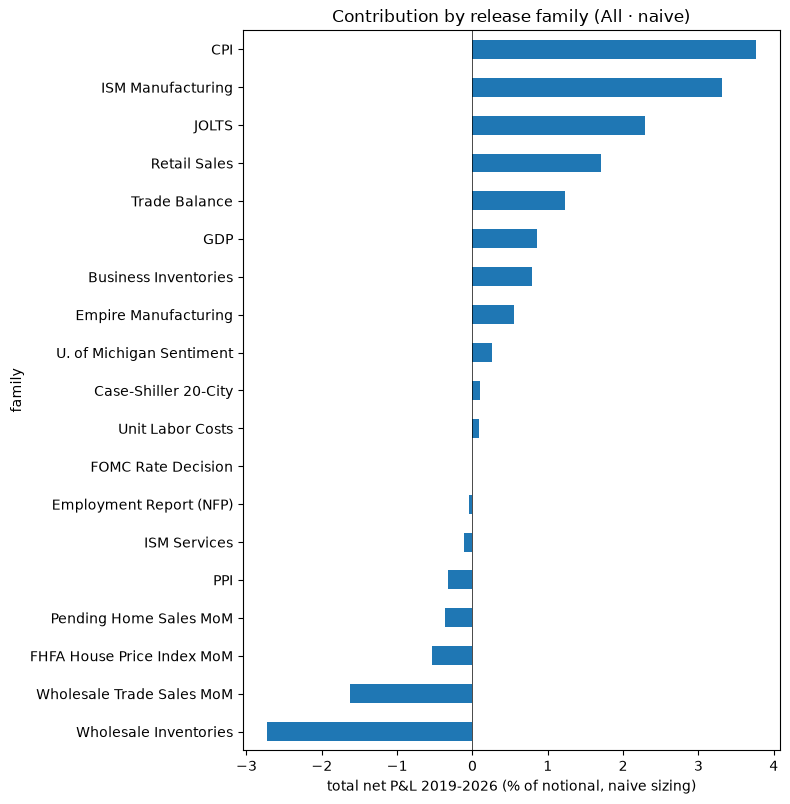

In [12]:
fam_naive = su.per_family_stats(P["All · naive"], PRIMARY_TARGET).add_prefix("naive_")
fam_vol = su.per_family_stats(P["All · signal × vol"], PRIMARY_TARGET).add_prefix("vol_")
fam_tab = fam_naive.join(fam_vol, how="outer").sort_values("naive_total_net_pct", ascending=False)
fam_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_per_family.csv")
display(fam_tab.round(3))

ax = fam_tab["naive_total_net_pct"].sort_values().plot.barh(figsize=(8, 0.35 * len(fam_tab) + 1.5), color="C0")
ax.axvline(0, c="k", lw=0.5); ax.set_xlabel("total net P&L 2019-2026 (% of notional, naive sizing)")
ax.set_title("Contribution by release family (All · naive)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_family_contribution.png", dpi=150); plt.show()

### 9.3 Cumulative P&L

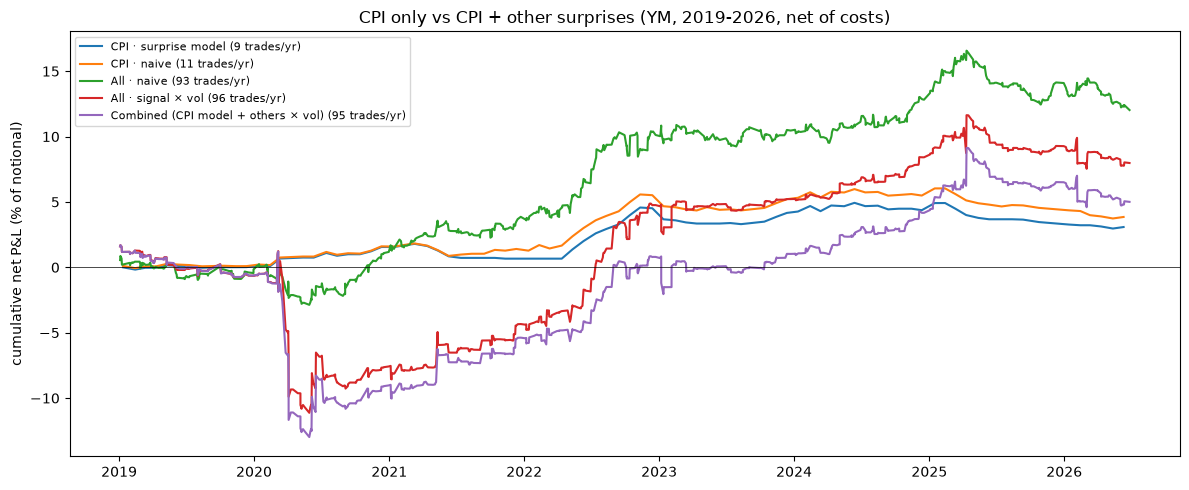

In [13]:
SHOW = ["CPI · surprise model", "CPI · naive", "All · naive", "All · signal × vol", "Combined (CPI model + others × vol)"]
fig, ax = plt.subplots(figsize=(12, 5))
for i, s in enumerate(SHOW):
    cum, _ = wf.drawdown_series(T[s], EVAL_START, EVAL_END)
    ax.plot(cum.index, cum.values, label=f"{s} ({perf.loc[s, 'trades_per_year']:.0f} trades/yr)", lw=1.5)
ax.axhline(0, c="k", lw=0.5); ax.set_ylabel("cumulative net P&L (% of notional)")
ax.set_title(f"CPI only vs CPI + other surprises ({MARKET}, 2019-2026, net of costs)")
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_cumulative_pnl.png", dpi=150); plt.show()

### 9.4 Robustness: sub-periods, 2022, and the random-sign null

In [14]:
def sharpe_months(tr, start, end, drop_year=None):
    m = wf.monthly_returns(tr, start, end)
    if drop_year:
        m = m[m.index.year != drop_year]
    sd = m.std(ddof=1)
    return m.mean() / sd * np.sqrt(12) if sd > 0 else np.nan

rob = []
for s in STRATS:
    obs, p_null = su.random_sign_pvalue(T[s], wf.monthly_returns, EVAL_START, EVAL_END, n=N_NULL)
    (lo, _, hi), _ = wf.bootstrap_sharpe(T[s], EVAL_START, EVAL_END, N_BOOT)
    rob.append(dict(strategy=s, sharpe=obs, ci_5=lo, ci_95=hi,
                    sharpe_2019_21=sharpe_months(T[s], "2019-01-01", "2021-12-31"),
                    sharpe_2022_26=sharpe_months(T[s], "2022-01-01", EVAL_END),
                    sharpe_ex_2022=sharpe_months(T[s], EVAL_START, EVAL_END, drop_year=2022),
                    p_random_sign=p_null))
rob = pd.DataFrame(rob).set_index("strategy")
rob.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_robustness.csv")
display(rob.round(3))

,sharpe,ci_5,ci_95,sharpe_2019_21,sharpe_2022_26,sharpe_ex_2022,p_random_sign
strategy,,,,,,,
CPI · naive,0.539,-0.178,1.283,0.714,0.489,-0.049,0.030
CPI · surprise model,0.453,-0.288,1.221,0.348,0.510,-0.153,0.060
CPI · signal × vol,0.609,-0.107,1.325,0.522,0.662,0.031,0.027
All · naive,0.681,0.083,1.374,0.610,0.719,0.399,0.006
All · surprise model,0.338,-0.354,0.914,0.003,0.571,0.129,0.061
All · signal × vol,0.292,-0.364,1.129,-0.299,1.096,-0.047,0.116
Combined (CPI model + others × vol),0.164,-0.468,0.980,-0.330,0.837,-0.043,0.184
All · naive · 2nd window,-0.152,-0.663,0.509,-0.676,0.369,-0.402,0.237
All · signal × vol · 2 windows,-0.122,-0.631,0.978,-0.747,1.017,-0.441,0.393


**How to read it.**
- **`p_random_sign`** is the share of random-direction books, with the same trades, sizes and costs, whose Sharpe beats the strategy. Below 0.05 means the *direction* genuinely adds value.
- **`sharpe_ex_2022`** shows how much depends on the 2022 inflation shock.

### 9.5 Transaction costs

In [15]:
cost_rows = []
for ticks in [0, 1, 2, 4]:
    pt = panel.copy()
    pt["cost_bps"] = su.cost_bps(pt["pre_close"], ticks, COMMISSION_RT, TICK, MULT)
    for s, (fams, model) in {"CPI · surprise model": ("cpi", "surprise"), "All · naive": ("all", "naive"),
                             "All · signal × vol": ("all", "signal_vol")}.items():
        sub = pt[pt["family"] == CPI] if fams == "cpi" else pt[pt["admitted"]]
        tr = su.to_trades(su.build_positions(sub, hist, model, PRIMARY_TARGET, MIN_TRAIN, THRESHOLD), PRIMARY_TARGET, s)
        pf = wf.performance(tr, EVAL_START, EVAL_END, s)
        cost_rows.append(dict(ticks_rt=ticks, strategy=s, sharpe_net=pf["sharpe_net"], avg_net_bps=pf["avg_net_bps"], trades=pf["trades"]))
cost_tab = pd.DataFrame(cost_rows)
cost_tab.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_cost_sensitivity.csv", index=False)
display(cost_tab.pivot(index="ticks_rt", columns="strategy", values="sharpe_net").round(2))

strategy,All · naive,All · signal × vol,CPI · surprise model
ticks_rt,,,
0,0.910,0.410,0.570
1,0.800,0.350,0.490
2,0.680,0.290,0.450
4,0.450,0.170,0.590


### 9.6 Peer-format metrics (daily, one contract)

In [16]:
daily_close = sc.build_daily_close(es_adj)
days = daily_close.index[(daily_close.index >= pd.Timestamp(EVAL_START)) & (daily_close.index <= pd.Timestamp(EVAL_END))]
bh = wf.buy_hold_daily(daily_close, days)
peer = {s: wf.peer_metrics(wf.daily_returns(T[s], days), bh, trades_per_year=perf.loc[s, "trades_per_year"],
                           minutes_in_market=perf.loc[s, "trades"] * 30 / (len(days) * 23 * 60) * 100) for s in STRATS}
peer = pd.DataFrame(peer).T
peer.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_peer_metrics.csv")
display(peer.round(3))

,total_pct,vol_pct,sharpe,max_dd_pct,beta,corr,trades_per_year,time_in_market_pct
CPI · naive,3.852,0.988,0.553,-2.301,-0.001,-0.015,11.343,0.104
CPI · surprise model,3.082,0.938,0.466,-1.965,-0.001,-0.013,8.808,0.081
CPI · signal × vol,7.485,1.706,0.622,-2.756,-0.004,-0.037,11.343,0.104
All · naive,12.029,2.543,0.670,-4.542,-0.000,-0.003,92.614,0.849
All · surprise model,5.696,2.134,0.378,-5.643,0.009,0.080,56.849,0.521
All · signal × vol,7.979,4.577,0.247,-12.821,-0.001,-0.002,96.484,0.884
Combined (CPI model + others × vol),5.007,4.407,0.161,-14.676,0.002,0.008,95.416,0.874
All · naive · 2nd window,-2.733,1.988,-0.195,-7.445,-0.005,-0.045,92.614,0.849
All · signal × vol · 2 windows,-6.713,6.482,-0.147,-29.157,-0.015,-0.041,192.967,1.768


## 10. Final Comparison: CPI Only vs CPI + Other Surprises

In [17]:
FINAL = ["CPI · naive", "CPI · surprise model", "CPI · signal × vol",
         "All · naive", "All · surprise model", "All · signal × vol",
         "Combined (CPI model + others × vol)", "All · signal × vol · 2 windows"]
final = pd.DataFrame({
    "trades / yr": perf.loc[FINAL, "trades_per_year"],
    "days / yr": perf.loc[FINAL, "days_per_year"],
    "hit rate": perf.loc[FINAL, "hit_rate"],
    "net bps / trade": perf.loc[FINAL, "avg_net_bps"],
    "total net P&L %": perf.loc[FINAL, "total_net_pct"],
    "ann. return %": perf.loc[FINAL, "ann_return_pct"],
    "ann. vol %": perf.loc[FINAL, "ann_vol_pct"],
    "Sharpe (net)": perf.loc[FINAL, "sharpe_net"],
    "Sharpe ex-2022": rob.loc[FINAL, "sharpe_ex_2022"],
    "max DD %": perf.loc[FINAL, "max_dd_pct"],
    "beta": peer.loc[FINAL, "beta"],
    "P(random sign ≥)": rob.loc[FINAL, "p_random_sign"],
})
jack = pd.DataFrame({"trades / yr": 185, "days / yr": np.nan, "hit rate": np.nan, "net bps / trade": 1.18,
                     "total net P&L %": 18.597, "ann. return %": np.nan, "ann. vol %": 3.020, "Sharpe (net)": 0.613,
                     "Sharpe ex-2022": np.nan, "max DD %": -4.928, "beta": -0.005, "P(random sign ≥)": np.nan},
                    index=["Peer: Jack DTW (slide, 2018-2026)"])
final = pd.concat([final, jack])
final.to_csv(RESULTS_DIR / f"nb05b_{MARKET}_final_comparison.csv")
display(final.round(3))

,trades / yr,days / yr,hit rate,net bps / trade,total net P&L %,ann. return %,ann. vol %,Sharpe (net),Sharpe ex-2022,max DD %,beta,P(random sign ≥)
CPI · naive,11.343,11.877,0.529,4.532,3.852,0.514,0.952,0.539,-0.049,-2.301,-0.001,0.030
CPI · surprise model,8.808,8.808,0.500,4.670,3.082,0.411,0.907,0.453,-0.153,-1.965,-0.001,0.060
CPI · signal × vol,11.343,11.343,0.529,8.806,7.485,0.998,1.640,0.609,0.031,-2.756,-0.004,0.027
All · naive,92.614,89.811,0.530,1.733,12.029,1.604,2.357,0.681,0.399,-4.542,-0.000,0.006
All · surprise model,56.849,53.780,0.505,1.337,5.696,0.759,2.246,0.338,0.129,-5.643,0.009,0.061
All · signal × vol,96.484,86.742,0.526,1.104,7.979,1.064,3.644,0.292,-0.047,-12.821,-0.001,0.116
Combined (CPI model + others × vol),95.416,85.674,0.523,0.700,5.007,0.668,4.060,0.164,-0.043,-14.676,0.002,0.184
All · signal × vol · 2 windows,192.967,86.742,0.507,-0.464,-6.713,-0.895,7.333,-0.122,-0.441,-29.177,-0.015,0.393
"Peer: Jack DTW (slide, 2018-2026)",185.000,NaN,NaN,1.180,18.597,NaN,3.020,0.613,NaN,-4.928,-0.005,NaN


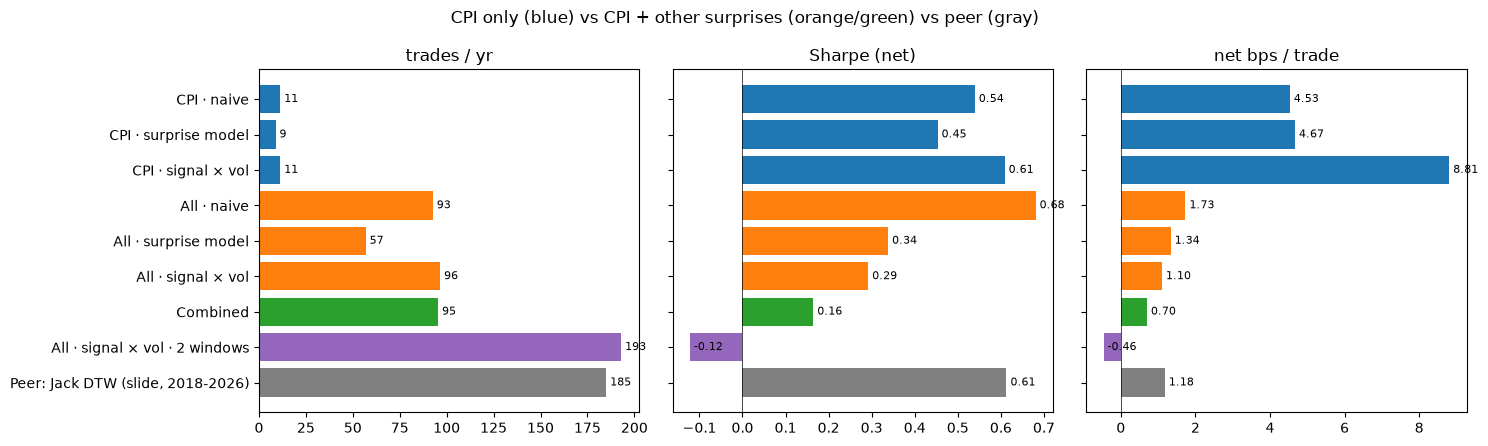

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
lab = [s.replace(" (CPI model + others × vol)", "") for s in final.index]
for ax, col in zip(axes, ["trades / yr", "Sharpe (net)", "net bps / trade"]):
    vals = final[col].values
    ax.barh(lab, vals, color=["C0"] * 3 + ["C1"] * 3 + ["C2", "C4", "gray"])
    ax.axvline(0, c="k", lw=0.5); ax.set_title(col); ax.invert_yaxis()
    for i, v in enumerate(vals):
        if np.isfinite(v):
            ax.text(v, i, f" {v:.2f}" if col != "trades / yr" else f" {v:.0f}", va="center", fontsize=8)
    if ax is not axes[0]:
        ax.set_yticklabels([])
plt.suptitle("CPI only (blue) vs CPI + other surprises (orange/green) vs peer (gray)")
plt.tight_layout(); plt.savefig(FIGURES_DIR / f"nb05b_{MARKET}_final_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

### 10.1 Automatic summary

In [19]:
def line(s):
    r = final.loc[s]
    return (f"{s:<40s} {r['trades / yr']:6.0f} trades/yr | Sharpe {r['Sharpe (net)']:5.2f} | "
            f"{r['net bps / trade']:6.2f} bps/trade | total {r['total net P&L %']:6.2f}% | "
            f"maxDD {r['max DD %']:6.2f}% | ex-2022 Sharpe {r['Sharpe ex-2022']:5.2f} | P(random) {r['P(random sign ≥)']:.3f}")
print("=" * 120)
print(f"NOTEBOOK 05 SUMMARY — {MARKET}, 2019-2026, net of costs")
print("=" * 120)
print("CPI only:")
for s in FINAL[:3]: print("  " + line(s))
print("CPI + other surprises:")
for s in FINAL[3:]: print("  " + line(s))
print(f"\nPeer (Jack DTW slide): 185 trades/yr | Sharpe 0.61 | 1.18 bps/trade | total 18.6% | maxDD -4.9%")
best = final.drop(index=final.index[-1])["Sharpe (net)"].idxmax()
print(f"\nHighest net Sharpe: {best}")
print(f"Families admitted at least once: {', '.join(sorted(admitted_any.index))}")

NOTEBOOK 05 SUMMARY — YM, 2019-2026, net of costs
CPI only:
  CPI · naive                                  11 trades/yr | Sharpe  0.54 |   4.53 bps/trade | total   3.85% | maxDD  -2.30% | ex-2022 Sharpe -0.05 | P(random) 0.030
  CPI · surprise model                          9 trades/yr | Sharpe  0.45 |   4.67 bps/trade | total   3.08% | maxDD  -1.97% | ex-2022 Sharpe -0.15 | P(random) 0.060
  CPI · signal × vol                           11 trades/yr | Sharpe  0.61 |   8.81 bps/trade | total   7.49% | maxDD  -2.76% | ex-2022 Sharpe  0.03 | P(random) 0.027
CPI + other surprises:
  All · naive                                  93 trades/yr | Sharpe  0.68 |   1.73 bps/trade | total  12.03% | maxDD  -4.54% | ex-2022 Sharpe  0.40 | P(random) 0.006
  All · surprise model                         57 trades/yr | Sharpe  0.34 |   1.34 bps/trade | total   5.70% | maxDD  -5.64% | ex-2022 Sharpe  0.13 | P(random) 0.061
  All · signal × vol                           96 trades/yr | Sharpe  0.29 |   1.1

## 11. Interpretation and Conclusion

*Fill this in after running, using the summary above. Suggested structure:*

**1. Trade count.** How many trades a year does CPI + other surprises give, compared with CPI only (about 7–11) and the peer strategy (185)?

**2. Edge per trade.** Does net bps per trade stay above the cost when weaker releases are added? Which families earn money (Section 9.2), and which only add costs?

**3. Risk-adjusted return.** Compare the Sharpe of CPI only, All, and Combined. Is the difference robust? Check `P(random sign ≥)`, the Sharpe excluding 2022, and the two sub-periods.

**4. Sizing.** Does Jack's signal × volatility sizing improve the multi-release book, as it did in his split test?

**5. Second window.** Does a second 30-minute trade after each release add profit, or only trades?

**6. Recommendation.** CPI only, CPI + others, or the combined book, and why.

# 12. Purpose, Research Questions, Answers, and Conclusion (YM)

## Purpose of Notebook 05b (YM)

Notebook 04b showed that trading YM in the direction of the **CPI surprise** is profitable after costs (naive sign Sharpe 0.99), but with only about 10 trades a year. Notebook 05b repeats Notebook 05 on the E-mini Dow and asks:

> **If we trade the surprises of many US macro releases on YM, not only CPI, how many trades do we get, and do we keep a positive, credible edge after costs?**

**Design (identical to Notebook 05):** entry at the close of the first post-release bar (T+1), exit 30 minutes after the release, walk-forward over **2019–2026**; each year, using only earlier releases, an impact screen picks the 10 families that move YM most, each line's sign comes from its historical first-minute reaction on YM, and costs are 2 ticks + $4.50 per round trip (about 1.0 bps on YM).

**Data check.** 179 Bloomberg lines group into 75 families with at least 30 releases. 5,708 of 6,097 release timestamps since 2016 have a complete 30-minute YM window. The 30-minute trade return is identical to Notebook 04b on all 77 matched CPI releases.

### Which releases does YM react to?

**Answer:** The same core as ES and NQ. **NFP** ranks first or second every year, **CPI** first from 2023, followed by the **FOMC decision** (and the Fed's interest-on-reserves line, which prints at the same minute), **ISM Manufacturing**, **ISM Services**, **Retail Sales**, JOLTS and PPI. U. of Michigan Sentiment enters the top 10 from 2023. Trade Balance ranked high in 2019–2022 and then dropped out.

### Does the signed signal relate to YM's reaction?

**Answer:** Yes, for the main families. The correlation between the family signal and YM's first-minute jump in 2019–2026 is **+0.54 for CPI**, +0.61 for U. of Michigan, +0.32 for PPI, +0.28 for Retail Sales and +0.25 for NFP. Case-Shiller (−0.63) and FHFA (−0.13) have the wrong sign out of sample: their historical signs did not carry over.

### Does trading many releases work?

**Answer:** Yes, with the simplest rule. Over 2019–2026, net of costs:

| Strategy | Trades / yr | Net bps / trade | Net Sharpe | 90% CI | Sharpe ex-2022 | Max DD | P(random sign) |
|---|---|---|---|---|---|---|---|
| CPI · naive | 11 | 4.5 | 0.54 | −0.18 to 1.28 | −0.05 | −2.3% | 0.030 |
| CPI · signal × vol | 11 | 8.8 | 0.61 | −0.11 to 1.33 | 0.03 | −2.8% | 0.027 |
| **All · naive** | **93** | 1.7 | **0.68** | **0.08 to 1.37** | **0.40** | −4.5% | **0.006** |
| All · surprise model | 57 | 1.3 | 0.34 | −0.35 to 0.91 | 0.13 | −5.6% | 0.061 |
| All · signal × vol | 96 | 1.1 | 0.29 | −0.36 to 1.13 | −0.05 | −12.8% | 0.116 |
| All · naive · 2nd window | 93 | −0.4 | −0.15 | −0.66 to 0.51 | −0.40 | −7.4% | 0.237 |

The **multi-release naive book** is the best YM result: about **93 trades a year on 90 days**, a net Sharpe of **0.68** with a 90% interval above zero, 12.0% total net P&L, and a direction that beats random signs (p = 0.006). It is the only book that stays clearly positive without 2022 (0.40). This is almost the same as ES (0.65) and NQ (0.71).

### Which releases earn money?

**Answer:** CPI (+3.8% naive, +6.3% with signal × vol), ISM Manufacturing (+3.3%), JOLTS (+2.3%), Retail Sales (+1.7%) and Trade Balance (+1.2%) earn the most. **NFP earns nothing** in YM (−0.05 bps per trade, 43% hit), and Wholesale Inventories (−2.7%) and Wholesale Trade Sales (−1.6%) lose. As in ES and NQ, the broad book is a diversified set of small edges, not one release.

### Does the edge last beyond 30 minutes?

**Answer:** No. Trading the second 30-minute window (T+30 to T+60) loses (−0.4 bps per trade, Sharpe −0.15), and the two-window book loses too (−0.12). The surprise's edge on YM is spent within the first 30 minutes, as in ES and NQ.

### Is it robust to costs and market-neutral?

**Answer:** Yes. The naive multi-release book has a Sharpe of 0.91 before costs, 0.68 at 2 ticks and 0.45 at 4 ticks. Beta to YM buy-and-hold is between −0.015 and +0.009 for every strategy, and time in market is below 1% (1.8% for the two-window book).

---

## The CPI Surprise Definition (as in ES and NQ)

The YM **CPI naive** book here (Sharpe 0.54) is weaker than in Notebook 04b (0.99), **with identical trade returns**. The reason is the same as in ES and NQ: Notebook 04 uses the headline CPI MoM surprise, while Notebook 05 averages all CPI lines, and the two disagree in direction on releases where the headline surprise is close to zero. The CPI-only books here also trade a few more releases (85 against 77), because the history requirement is shorter.

---

## Final Comparison: CPI Only vs CPI + Other Surprises (YM)

| | **CPI only** (best: signal × vol) | **CPI + other surprises** (All · naive) | Peer: Jack DTW (ES) |
|---|---|---|---|
| Trades per year | 11 | **93** | 185 |
| Trading days per year | 11 | **90** | — |
| Net bps per trade | **8.8** | 1.7 | 1.2 |
| Total net P&L (2019–26) | 7.5% | **12.0%** | 18.6% (2018–26) |
| Net Sharpe | 0.61 | **0.68** | 0.61 |
| Max drawdown | −2.8% | −4.5% | −4.9% |
| Sharpe ex-2022 | 0.03 | **0.40** | — |
| Sharpe at 4-tick costs | — | **0.45** | — |

---

## Conclusion

**1. YM supports a broad macro-surprise book.** Trading the surprises of about 10 screened releases gives **~93 trades a year on ~90 days**, against about 11 for CPI only.

**2. The edge matches ES and NQ.** The multi-release naive book earns a **net Sharpe of 0.68** (ES 0.65, NQ 0.71), with a −4.5% drawdown and a direction that beats random signs (p = 0.006). It is the only YM book that remains positive without 2022.

**3. Simple beats fitted.** The surprise model and the volatility-scaled versions do worse than trading the sign; sizing by volatility mainly adds drawdown (−12.8%).

**4. The edge lasts about 30 minutes.** The second window loses, as in ES and NQ.

**5. Caveats:** the screen admits some families whose historical signs failed out of sample (Case-Shiller, FHFA, Wholesale Inventories); NFP, the top-ranked release by impact, earns nothing in YM; and returns are per unit of notional before leverage.

> **Overall:** on YM, trading the macro surprise across about 10 major US releases gives ~93 trades a year with a net Sharpe of 0.68, close to ES and NQ. YM is a third equity market for the same strategy; Notebook 06b tests whether DTW adds anything on YM, and Notebook 07b whether adding YM to ES and NQ improves the portfolio.
